 Imports & Load

In [1]:
import pandas as pd

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay, roc_curve)
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('charts', exist_ok=True)

df = pd.read_csv('cleaned_noshow_data.csv')
print("Shape:", df.shape)

Shape: (71954, 24)


Prepare Features

In [3]:
# Encode categorical columns
le = LabelEncoder()
df['gender_enc'] = le.fit_transform(df['gender'])
df['age_group_enc'] = le.fit_transform(df['age_group'].astype(str))
df['waiting_bucket_enc'] = le.fit_transform(df['waiting_bucket'].astype(str))
df['weekday_enc'] = le.fit_transform(df['appointment_weekday'].astype(str))

# Final feature set
feature_cols = [
    'age', 'waiting_days', 'scholarship', 'hypertension',
    'diabetes', 'alcoholism', 'handicap', 'sms_received',
    'same_day', 'has_chronic', 'is_returning', 'total_visits',
    'gender_enc', 'age_group_enc', 'waiting_bucket_enc', 'weekday_enc'
]

X = df[feature_cols]
y = df['no_show_flag']

print("Features:", X.shape)
print("Target distribution:\n", y.value_counts())
print(f"\nNo-show rate: {y.mean()*100:.1f}%")

Features: (71954, 16)
Target distribution:
 no_show_flag
0    51435
1    20519
Name: count, dtype: int64

No-show rate: 28.5%


Train Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (57563, 16)
Test: (14391, 16)


 Train Models

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Both models trained ✅")

Both models trained ✅


 Evaluate Both Models

In [6]:
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_prob)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred,
          target_names=['Showed Up', 'No Show']))
    print(f"ROC-AUC: {auc:.4f}")
    return auc, y_prob

lr_auc, lr_prob = evaluate_model("Logistic Regression", lr, X_test_sc, y_test)
rf_auc, rf_prob = evaluate_model("Random Forest",       rf, X_test,    y_test)


  Logistic Regression
              precision    recall  f1-score   support

   Showed Up       0.77      0.56      0.65     10287
     No Show       0.34      0.57      0.43      4104

    accuracy                           0.56     14391
   macro avg       0.55      0.57      0.54     14391
weighted avg       0.65      0.56      0.58     14391

ROC-AUC: 0.5955

  Random Forest
              precision    recall  f1-score   support

   Showed Up       0.73      0.82      0.77     10287
     No Show       0.35      0.25      0.29      4104

    accuracy                           0.66     14391
   macro avg       0.54      0.53      0.53     14391
weighted avg       0.62      0.66      0.64     14391

ROC-AUC: 0.5667


 ROC Curve

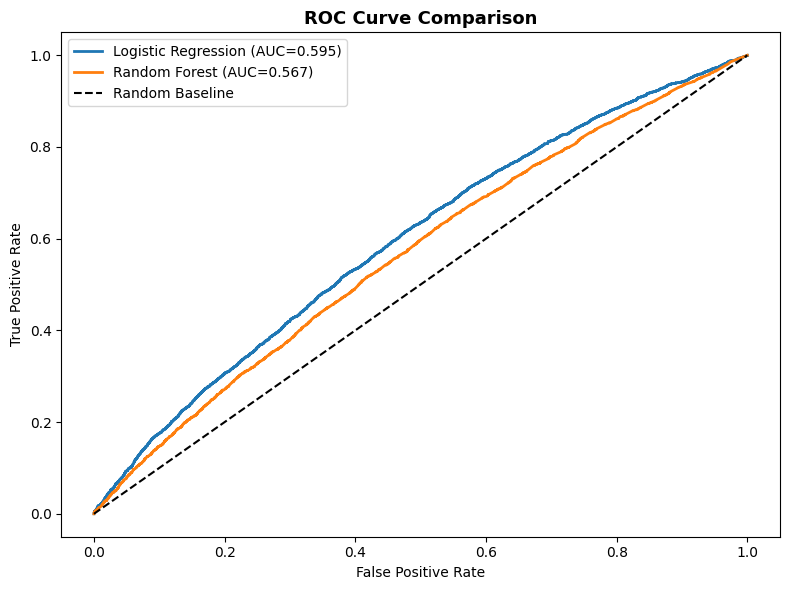

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, prob, auc in [
    ("Logistic Regression", lr_prob, lr_auc),
    ("Random Forest",       rf_prob, rf_auc)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc:.3f})")

ax.plot([0,1],[0,1], 'k--', label='Random Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('charts/08_roc_curve.png', dpi=150)
plt.show()

 Feature Importance

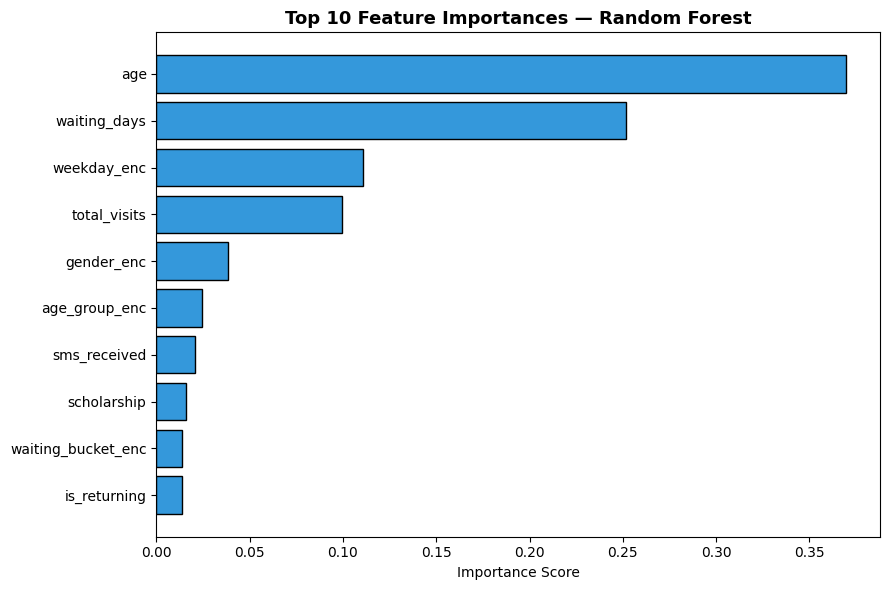

In [8]:
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(feat_imp['feature'], feat_imp['importance'],
        color='#3498db', edgecolor='black')
ax.set_title('Top 10 Feature Importances — Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('charts/09_feature_importance.png', dpi=150)
plt.show()

Business Recommendations

In [9]:
print("=" * 60)
print("   BUSINESS RECOMMENDATIONS")
print("=" * 60)
print("""
1. WAITING TIME IS THE STRONGEST PREDICTOR
   → Patients waiting 30+ days are most likely to miss.
   → Recommend: Send reminders at Day 1, Day 7, Day 25.

2. SMS REMINDERS ARE NOT WORKING AS EXPECTED
   → Patients who got SMS had HIGHER no-show rates.
   → Likely because SMS is sent to high-risk patients already.
   → Recommend: Improve SMS timing and personalization.

3. YOUNG ADULTS (18-35) MISS MOST APPOINTMENTS
   → Recommend: WhatsApp/app-based reminders for this group.

4. SAME-DAY APPOINTMENTS HAVE LOWEST NO-SHOW RATE
   → Recommend: Keep emergency/same-day slots available.

5. RETURNING PATIENTS ARE MORE RELIABLE
   → Recommend: Priority scheduling for loyal patients.
   → First-time patients need extra follow-up.
""")
print("=" * 60)

   BUSINESS RECOMMENDATIONS

1. WAITING TIME IS THE STRONGEST PREDICTOR
   → Patients waiting 30+ days are most likely to miss.
   → Recommend: Send reminders at Day 1, Day 7, Day 25.

2. SMS REMINDERS ARE NOT WORKING AS EXPECTED
   → Patients who got SMS had HIGHER no-show rates.
   → Likely because SMS is sent to high-risk patients already.
   → Recommend: Improve SMS timing and personalization.

3. YOUNG ADULTS (18-35) MISS MOST APPOINTMENTS
   → Recommend: WhatsApp/app-based reminders for this group.

4. SAME-DAY APPOINTMENTS HAVE LOWEST NO-SHOW RATE
   → Recommend: Keep emergency/same-day slots available.

5. RETURNING PATIENTS ARE MORE RELIABLE
   → Recommend: Priority scheduling for loyal patients.
   → First-time patients need extra follow-up.

